   age  gender primary_diagnosis  num_procedures  days_in_hospital  \
0   69    Male     Heart Disease               1                 2   
1   32  Female              COPD               2                13   
2   89    Male          Diabetes               1                 7   
3   78    Male              COPD               9                 2   
4   38    Male          Diabetes               6                 4   

   comorbidity_score              discharge_to  readmitted  
0                  1          Home Health Care           0  
1                  2   Rehabilitation Facility           0  
2                  1                      Home           0  
3                  2  Skilled Nursing Facility           0  
4                  4   Rehabilitation Facility           0  
(5000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0 

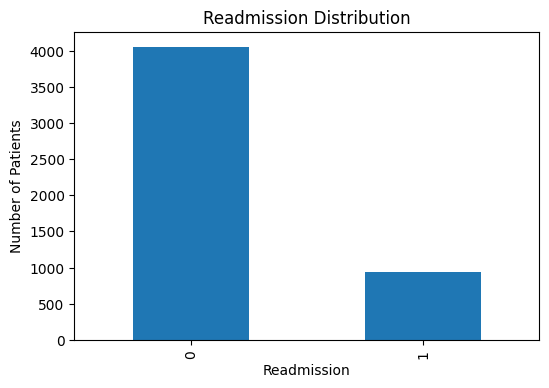

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MODEL PERFORMANCE
-----------------
Accuracy : 0.812
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5067111675924956

Confusion Matrix:
[[812   0]
 [188   0]]


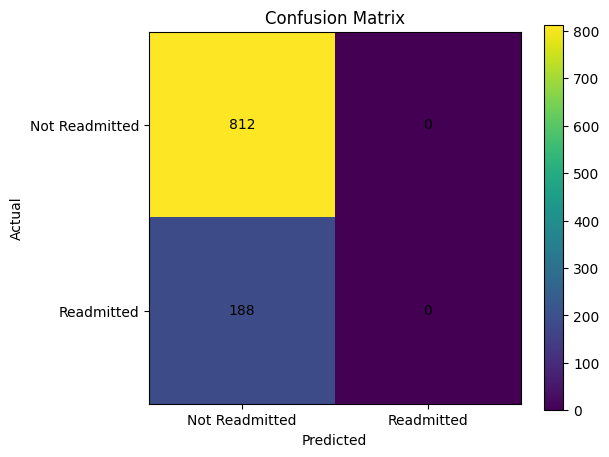

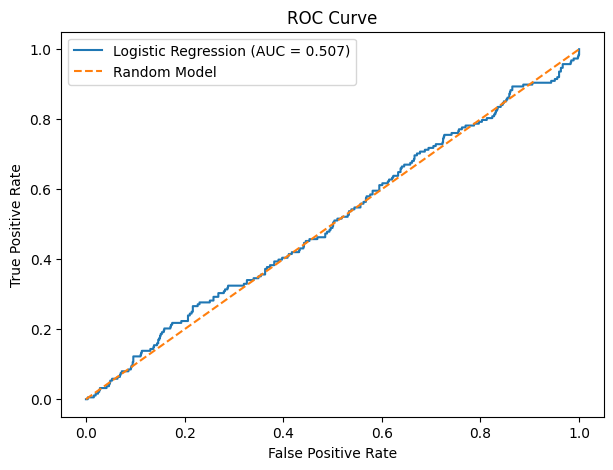


Feature Coefficients:
                                  Feature  Coefficient
10       primary_diagnosis_Kidney Disease     0.076682
12          discharge_to_Home Health Care     0.074591
4                           gender_Female     0.046963
0                                     age     0.029651
11                      discharge_to_Home     0.028126
7              primary_diagnosis_Diabetes     0.012612
13   discharge_to_Rehabilitation Facility     0.008695
6                  primary_diagnosis_COPD    -0.003875
3                       comorbidity_score    -0.014503
1                          num_procedures    -0.022260
8         primary_diagnosis_Heart Disease    -0.034437
2                        days_in_hospital    -0.036549
5                             gender_Male    -0.039194
9          primary_diagnosis_Hypertension    -0.043214
14  discharge_to_Skilled Nursing Facility    -0.103642

Submission created successfully!
   Patient_ID  readmitted
0           1           0
1          

In [2]:
# ==========================================
# HOSPITAL READMISSION PREDICTION
# L2 LOGISTIC REGRESSION
# ==========================================

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# 2. LOAD DATA

train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")
sample_submission = pd.read_csv("sample_submission.csv")


# 3. BASIC UNDERSTANDING

print(train_df.head())
print(train_df.shape)
print(train_df.info())
print(train_df.describe())


# 4. CHECK MISSING VALUES

print(train_df.isnull().sum())


# 5. TARGET DISTRIBUTION

print(train_df['readmitted'].value_counts())

plt.figure(figsize=(6,4))
train_df['readmitted'].value_counts().plot(kind='bar')
plt.xlabel("Readmission")
plt.ylabel("Number of Patients")
plt.title("Readmission Distribution")
plt.show()


# 6. SEPARATE FEATURES AND TARGET

X = train_df.drop('readmitted', axis=1)
y = train_df['readmitted']


# 7. CONVERT CATEGORICAL VARIABLES

combined = pd.concat([X, test_df], axis=0)

combined = pd.get_dummies(
    combined,
    columns=[
        'gender',
        'primary_diagnosis',
        'discharge_to'
    ],
    dtype=int
)

X = combined.iloc[:len(X)].copy()
X_test = combined.iloc[len(X):].copy()


# 8. TRAIN-VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 9. SCALE NUMERICAL FEATURES

numeric_columns = [
    'age',
    'num_procedures',
    'days_in_hospital',
    'comorbidity_score'
]

mean = X_train[numeric_columns].mean()
std = X_train[numeric_columns].std()

X_train[numeric_columns] = (
    X_train[numeric_columns] - mean
) / std

X_val[numeric_columns] = (
    X_val[numeric_columns] - mean
) / std


# 10. LOGISTIC REGRESSION WITH L2

model = LogisticRegression(
    penalty='l2',
    max_iter=1000
)


# 11. TRAIN MODEL

model.fit(X_train, y_train)


# 12. PREDICTIONS

y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]


# 13. EVALUATION

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_prob)

print("\nMODEL PERFORMANCE")
print("-----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)


# 14. CONFUSION MATRIX

cm = confusion_matrix(y_val, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(
    [0,1],
    ['Not Readmitted', 'Readmitted']
)

plt.yticks(
    [0,1],
    ['Not Readmitted', 'Readmitted']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha='center',
            va='center'
        )

plt.show()


# 15. ROC CURVE

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    label='Random Model'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


# 16. COEFFICIENT ANALYSIS

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature Coefficients:")
print(coefficients)


# 17. FINAL MODEL ON COMPLETE DATA

X_full = X.copy()
X_test = X_test.copy()

mean = X_full[numeric_columns].mean()
std = X_full[numeric_columns].std()

X_full[numeric_columns] = (
    X_full[numeric_columns] - mean
) / std

X_test[numeric_columns] = (
    X_test[numeric_columns] - mean
) / std


final_model = LogisticRegression(
    penalty='l2',
    max_iter=1000
)

final_model.fit(X_full, y)


# 18. TEST PREDICTIONS

test_predictions = final_model.predict(X_test)


# 19. CREATE SUBMISSION

submission = sample_submission.copy()

submission['readmitted'] = test_predictions

submission.to_csv(
    'submission.csv',
    index=False
)

print("\nSubmission created successfully!")
print(submission.head())